Dataset shape: (161, 14)
Training samples: 128
Testing samples: 33

Closed Form Solution:
MSE: 23062.22989175654
R²: 0.9593179111625627

Gradient Descent Solution:
MSE: 250811.25423712516
R²: 0.5575655184171511


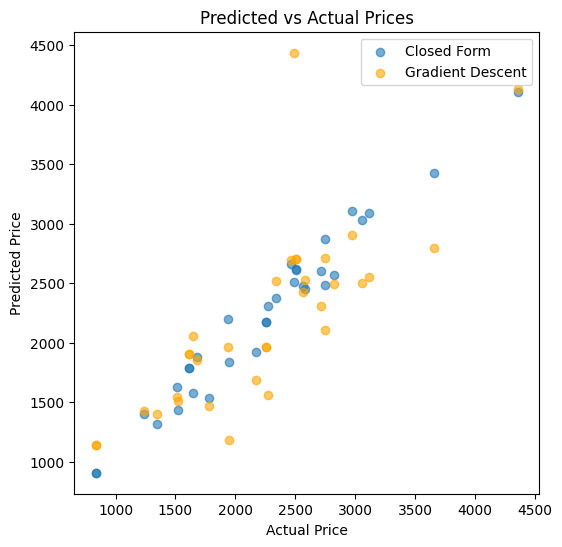


Ridge Regression (λ=0.1):
MSE: 23065.08476269461
R²: 0.959312875131196

With Standardization:
MSE: 23079.191540303156
R²: 0.9592879905826257

Without Standardization:
MSE: 23065.08476269461
R²: 0.959312875131196


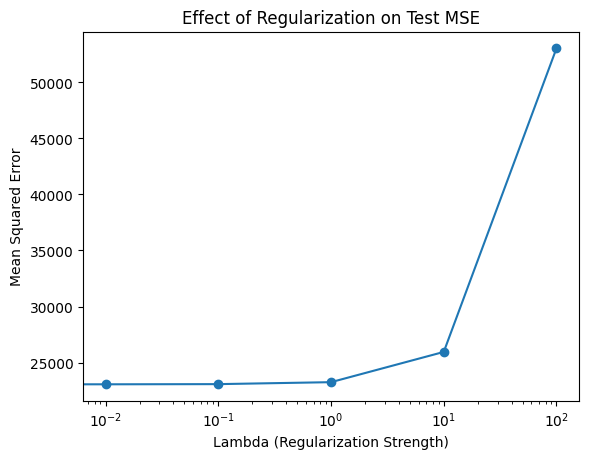


Feature Importance (Top 10):
         Feature  Importance
11       battery  176.779825
8            ram  162.182656
12     thickness  161.003520
7   internal mem  154.777959
4            ppi  153.071214
5       cpu core  121.732962
2         weight   75.259826
3    resoloution   75.121473
6       cpu freq   73.319794
10     Front_Cam   34.226373


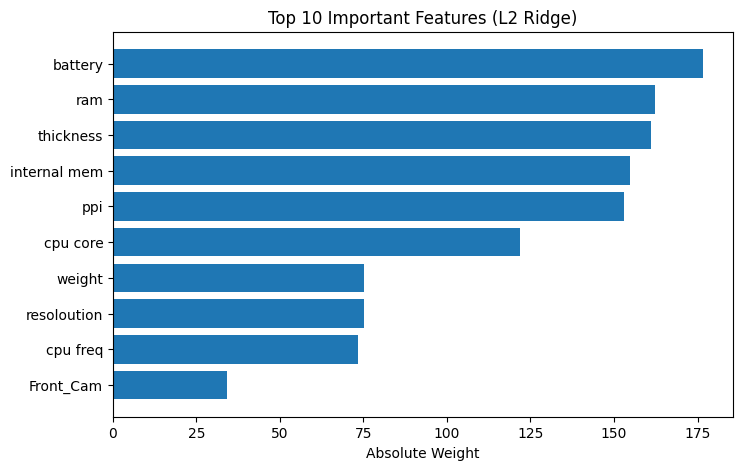


Summary of Performance:
             Method            MSE        R²
0       Closed Form   23062.229892  0.959318
1  Gradient Descent  250811.254237  0.557566
2    Ridge (No Std)   23065.084763  0.959313
3       Ridge (Std)   23079.191540  0.959288


In [7]:

# Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("Cellphone.csv")  # Downloaded from Kaggle

print("Dataset shape:", df.shape)
df.head()


# Define features (X) and target (y)

X = df.drop('Price', axis=1).values
y = df['Price'].values.reshape(-1, 1)


# Split into train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# 1. Linear Regression using Closed-Form (Normal Equation)

w_closed = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train
y_pred_closed = X_test_bias @ w_closed

mse_closed = mean_squared_error(y_test, y_pred_closed)
r2_closed = r2_score(y_test, y_pred_closed)

print("\nClosed Form Solution:")
print("MSE:", mse_closed)
print("R²:", r2_closed)

# 2️ Linear Regression using Gradient Descent

def gradient_descent(X, y, lr=0.00000001, epochs=1000):
    m, n = X.shape
    w = np.zeros((n, 1))
    for i in range(epochs):
        gradient = (2/m) * X.T @ (X @ w - y)
        w -= lr * gradient
    return w

w_gd = gradient_descent(X_train_bias, y_train, lr=0.00000001, epochs=2000)
y_pred_gd = X_test_bias @ w_gd

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("\nGradient Descent Solution:")
print("MSE:", mse_gd)
print("R²:", r2_gd)


# 3️ Plot Predicted vs Actual (Closed Form vs GD)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_closed, alpha=0.6, label='Closed Form')
plt.scatter(y_test, y_pred_gd, alpha=0.6, label='Gradient Descent', color='orange')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.title("Predicted vs Actual Prices")
plt.show()


# 4️ Add L2 Regularization (Ridge Regression)

def closed_form_ridge(X, y, lam=0.1):
    n = X.shape[1]
    I = np.eye(n)
    I[0,0] = 0  # don't regularize bias
    w = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
    return w

lam = 0.1
w_ridge = closed_form_ridge(X_train_bias, y_train, lam)
y_pred_ridge = X_test_bias @ w_ridge

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression (λ=0.1):")
print("MSE:", mse_ridge)
print("R²:", r2_ridge)


# 5️ Compare with and without Standardization

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_scaled_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

w_ridge_std = closed_form_ridge(X_train_scaled_bias, y_train, lam)
y_pred_ridge_std = X_test_scaled_bias @ w_ridge_std

mse_ridge_std = mean_squared_error(y_test, y_pred_ridge_std)
r2_ridge_std = r2_score(y_test, y_pred_ridge_std)

print("\nWith Standardization:")
print("MSE:", mse_ridge_std)
print("R²:", r2_ridge_std)

print("\nWithout Standardization:")
print("MSE:", mse_ridge)
print("R²:", r2_ridge)


# 6️ Plot λ vs MSE

lambdas = [0, 0.01, 0.1, 1, 10, 100]
mse_list = []

for lam in lambdas:
    w = closed_form_ridge(X_train_scaled_bias, y_train, lam)
    y_pred = X_test_scaled_bias @ w
    mse_list.append(mean_squared_error(y_test, y_pred))

plt.figure()
plt.plot(lambdas, mse_list, marker='o')
plt.xscale('log')
plt.xlabel("Lambda (Regularization Strength)")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Regularization on Test MSE")
plt.show()


# 7️ Feature Importance from L2 Weights

feature_names = df.drop('Price', axis=1).columns
importance = np.abs(w_ridge_std[1:].flatten())

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance (Top 10):")
print(feature_importance.head(10))


plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'].head(10),
         feature_importance['Importance'].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (L2 Ridge)")
plt.xlabel("Absolute Weight")
plt.show()


print("\nSummary of Performance:")
summary = pd.DataFrame({
    "Method": ["Closed Form", "Gradient Descent", "Ridge (No Std)", "Ridge (Std)"],
    "MSE": [mse_closed, mse_gd, mse_ridge, mse_ridge_std],
    "R²": [r2_closed, r2_gd, r2_ridge, r2_ridge_std]
})
print(summary)


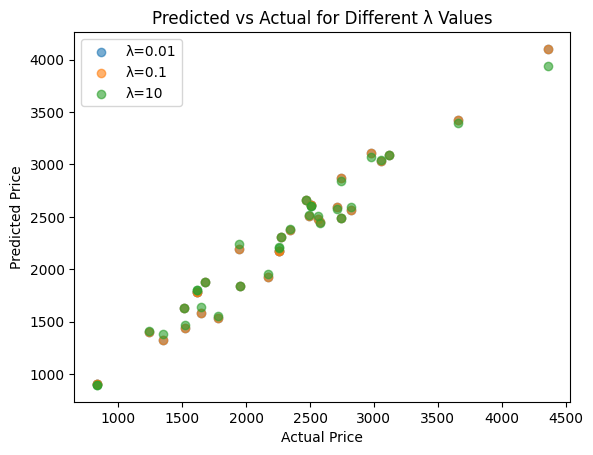

In [8]:

for lam in [0.01, 0.1, 10]:
    w = closed_form_ridge(X_train_scaled_bias, y_train, lam)
    y_pred = X_test_scaled_bias @ w
    plt.scatter(y_test, y_pred, alpha=0.6, label=f'λ={lam}')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual for Different λ Values")
plt.legend()
plt.show()


Dataset shape: (1372, 5)
Train samples: 1097
Test samples: 275

Without Regularization Accuracy: 0.9854545454545455
With L2 Regularization Accuracy: 0.9709090909090909


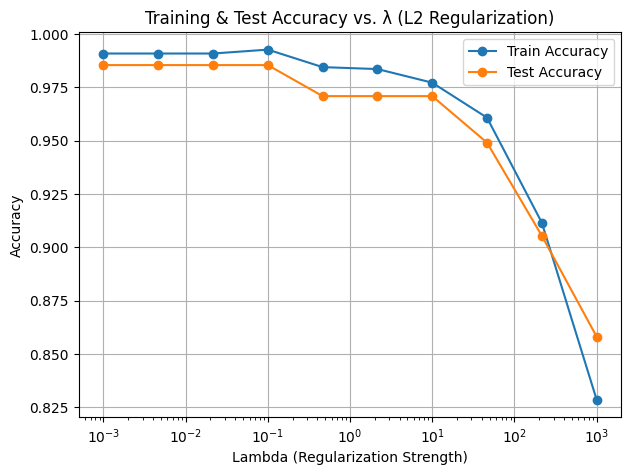

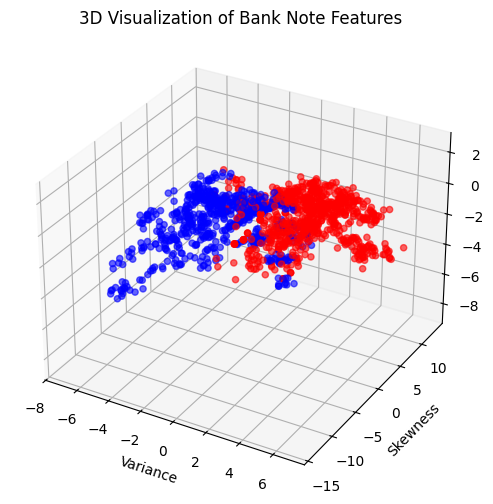


Accuracy with Outliers: 0.9454545454545454
Original L2 Accuracy (no outliers): 0.9709090909090909


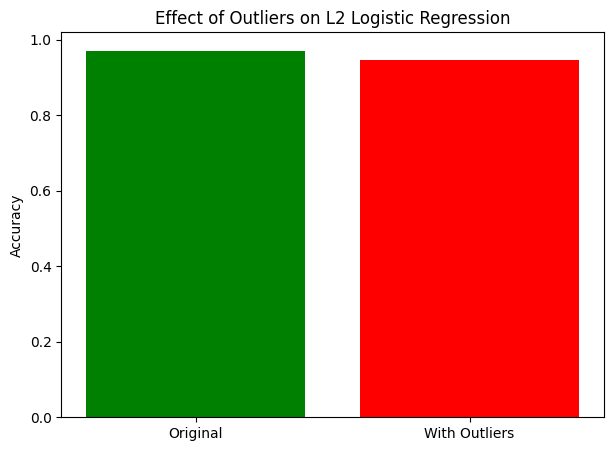


Summary of Results:
                Condition  Accuracy
0  Without Regularization  0.985455
1  With L2 Regularization  0.970909
2           With Outliers  0.945455


In [9]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt",
                 names=['variance', 'skewness', 'curtosis', 'entropy', 'class'])

print("Dataset shape:", df.shape)
df.head()


# 1️ Divide dataset into train/test sets (3 marks)

X = df.drop('class', axis=1).values
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


# 2️ Fit Linear Classifier with and without L2 regularization (6 marks)


# Without Regularization (set C very large)
log_reg_no_reg = LogisticRegression(penalty=None, max_iter=1000)
log_reg_no_reg.fit(X_train_scaled, y_train)

# With L2 Regularization
log_reg_l2 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000)
log_reg_l2.fit(X_train_scaled, y_train)

# Predictions
y_pred_no_reg = log_reg_no_reg.predict(X_test_scaled)
y_pred_l2 = log_reg_l2.predict(X_test_scaled)

# Accuracy
acc_no_reg = accuracy_score(y_test, y_pred_no_reg)
acc_l2 = accuracy_score(y_test, y_pred_l2)

print("\nWithout Regularization Accuracy:", acc_no_reg)
print("With L2 Regularization Accuracy:", acc_l2)


# 3️ Plot training and test accuracy vs λ (3 marks)

lambdas = np.logspace(-3, 3, 10)   # λ values
train_acc, test_acc = [], []

for lam in lambdas:
    model = LogisticRegression(penalty='l2', C=1/lam, solver='lbfgs', max_iter=1000)
    model.fit(X_train_scaled, y_train)
    train_acc.append(model.score(X_train_scaled, y_train))
    test_acc.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(7,5))
plt.semilogx(lambdas, train_acc, marker='o', label='Train Accuracy')
plt.semilogx(lambdas, test_acc, marker='o', label='Test Accuracy')
plt.xlabel("Lambda (Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Training & Test Accuracy vs. λ (L2 Regularization)")
plt.legend()
plt.grid(True)
plt.show()


# 4️ Visualize 3D plot using three important features

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
colors = ['red' if label==0 else 'blue' for label in y]
ax.scatter(df['variance'], df['skewness'], df['entropy'], c=colors, alpha=0.6)
ax.set_xlabel('Variance')
ax.set_ylabel('Skewness')
ax.set_zlabel('Entropy')
ax.set_title("3D Visualization of Bank Note Features")
plt.show()
# 5️ Intentionally introduce outliers by shifting data points

df_outlier = df.copy()
mask = df_outlier.sample(frac=0.05, random_state=1).index  # 5% data
df_outlier.loc[mask, ['variance', 'skewness']] += 5  # shift values

# Re-split data
X_out = df_outlier.drop('class', axis=1).values
y_out = df_outlier['class'].values
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_out, y_out, test_size=0.2, random_state=42, stratify=y_out
)

X_train_o = scaler.fit_transform(X_train_o)
X_test_o = scaler.transform(X_test_o)


# 6️ Fit classifier on outlier-injected data and comment on impact

model_outlier = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000)
model_outlier.fit(X_train_o, y_train_o)

y_pred_out = model_outlier.predict(X_test_o)
acc_outlier = accuracy_score(y_test_o, y_pred_out)

print("\nAccuracy with Outliers:", acc_outlier)
print("Original L2 Accuracy (no outliers):", acc_l2)


plt.figure(figsize=(7,5))
plt.bar(['Original', 'With Outliers'], [acc_l2, acc_outlier], color=['green', 'red'])
plt.ylabel("Accuracy")
plt.title("Effect of Outliers on L2 Logistic Regression")
plt.show()

summary = pd.DataFrame({
    "Condition": ["Without Regularization", "With L2 Regularization", "With Outliers"],
    "Accuracy": [acc_no_reg, acc_l2, acc_outlier]
})
print("\nSummary of Results:")
print(summary)
